# NLP Project 9: Student Feedback Analysis


Step 1: Import Libraries

In [ ]:
import pandas as pd
import nltk
import matplotlib.pyplot as plt
import string

from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from nltk.stem import WordNetLemmatizer

from textblob import TextBlob

from wordcloud import WordCloud

Step 2: Download NLTK Resources

In [ ]:
nltk.download('punkt')
nltk.download('stopwords')
nltk.download('wordnet')

[nltk_data] Downloading package punkt to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
[nltk_data] Downloading package wordnet to /root/nltk_data...


True

Step 3: Create Student Feedback Dataset

In [ ]:
feedback = {
    "Feedback": [
        "The faculty explains concepts very clearly.",
        "The syllabus is too lengthy.",
        "Practical sessions are very helpful.",
        "The classroom projector is not working properly.",
        "Assignments improve understanding.",
        "Too many assignments every week.",
        "Faculty is friendly and supportive.",
        "Need more industry-related projects.",
        "Lab equipment should be upgraded.",
        "Excellent teaching methods.",
        "Class timing should be more flexible.",
        "Notes provided are very useful.",
        "Need more interactive sessions.",
        "The course content is interesting.",
        "Placement training should start earlier."
    ]
}

df = pd.DataFrame(feedback)

df.head()

,Feedback
0,The faculty explains concepts very clearly.
1,The syllabus is too lengthy.
2,Practical sessions are very helpful.
3,The classroom projector is not working properly.
4,Assignments improve understanding.


Step 4: Preprocess Text

In [ ]:
nltk.download('punkt_tab')
stop_words = set(stopwords.words('english'))
lemmatizer = WordNetLemmatizer()

def preprocess(text):

    text = text.lower()

    text = text.translate(str.maketrans('', '', string.punctuation))

    words = word_tokenize(text)

    words = [word for word in words if word not in stop_words]

    words = [lemmatizer.lemmatize(word) for word in words]

    return " ".join(words)

df["Processed_Feedback"] = df["Feedback"].apply(preprocess)

df.head()

[nltk_data] Downloading package punkt_tab to /root/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.


,Feedback,Processed_Feedback
0,The faculty explains concepts very clearly.,faculty explains concept clearly
1,The syllabus is too lengthy.,syllabus lengthy
2,Practical sessions are very helpful.,practical session helpful
3,The classroom projector is not working properly.,classroom projector working properly
4,Assignments improve understanding.,assignment improve understanding


Step 5: Sentiment Analysis

In [ ]:
def get_sentiment(text):

    polarity = TextBlob(text).sentiment.polarity

    if polarity > 0:
        return "Positive"

    elif polarity < 0:
        return "Negative"

    else:
        return "Neutral"

df["Sentiment"] = df["Processed_Feedback"].apply(get_sentiment)

df

,Feedback,Processed_Feedback,Sentiment
0,The faculty explains concepts very clearly.,faculty explains concept clearly,Positive
1,The syllabus is too lengthy.,syllabus lengthy,Neutral
2,Practical sessions are very helpful.,practical session helpful,Neutral
3,The classroom projector is not working properly.,classroom projector working properly,Neutral
4,Assignments improve understanding.,assignment improve understanding,Neutral
5,Too many assignments every week.,many assignment every week,Positive
6,Faculty is friendly and supportive.,faculty friendly supportive,Positive
7,Need more industry-related projects.,need industryrelated project,Neutral
8,Lab equipment should be upgraded.,lab equipment upgraded,Neutral
9,Excellent teaching methods.,excellent teaching method,Positive


Step 6: Count Sentiments

In [ ]:
sentiment_count = df["Sentiment"].value_counts()

print(sentiment_count)

Sentiment
Neutral     9
Positive    6
Name: count, dtype: int64


Step 7: Plot Sentiment Distribution

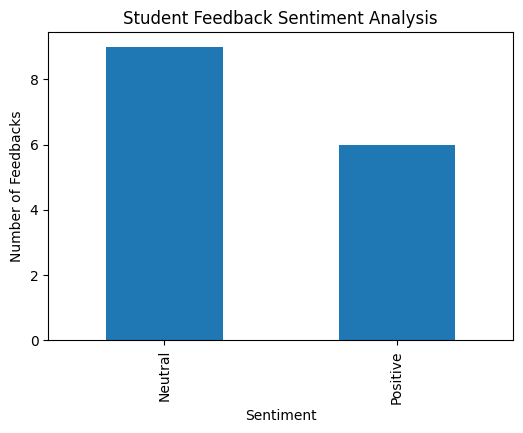

In [ ]:
plt.figure(figsize=(6,4))

sentiment_count.plot(kind='bar')

plt.title("Student Feedback Sentiment Analysis")

plt.xlabel("Sentiment")

plt.ylabel("Number of Feedbacks")

plt.show()

Step 8: Generate Word Cloud

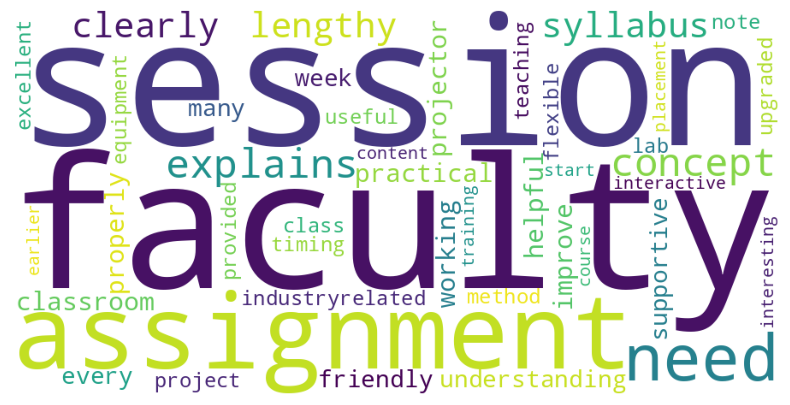

In [ ]:
text = " ".join(df["Processed_Feedback"])

wordcloud = WordCloud(width=900,
                      height=450,
                      background_color="white").generate(text)

plt.figure(figsize=(10,5))

plt.imshow(wordcloud)

plt.axis("off")

plt.show()

Step 9: Product Improvement Areas

In [ ]:
negative_feedback = df[df["Sentiment"] == "Negative"]

print(negative_feedback[["Feedback"]])

Empty DataFrame
Columns: [Feedback]
Index: []


Step 10: Improvement Suggestions

In [ ]:
suggestions = [
    "Reduce syllabus overload where possible.",
    "Balance assignment workload.",
    "Upgrade classroom equipment.",
    "Improve laboratory facilities.",
    "Introduce more industry-based projects.",
    "Conduct interactive learning sessions.",
    "Start placement preparation earlier."
]

for i, suggestion in enumerate(suggestions, start=1):
    print(f"{i}. {suggestion}")

1. Reduce syllabus overload where possible.
2. Balance assignment workload.
3. Upgrade classroom equipment.
4. Improve laboratory facilities.
5. Introduce more industry-based projects.
6. Conduct interactive learning sessions.
7. Start placement preparation earlier.


Step 11: Summary Statistics

In [ ]:
positive = len(df[df["Sentiment"]=="Positive"])
negative = len(df[df["Sentiment"]=="Negative"])
neutral = len(df[df["Sentiment"]=="Neutral"])

print("Positive Feedback :", positive)
print("Negative Feedback :", negative)
print("Neutral Feedback  :", neutral)

Positive Feedback : 6
Negative Feedback : 0
Neutral Feedback  : 9
